In [1]:
"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # 1 = animate, 0 = inanimate

def smooth_labels(y, alpha):
    """
    y: {0,1}
    alpha in [0,1]
    returns soft labels in [0,1]
    """
    return (1 - alpha) * y + 0.5 * alpha

def fit_logreg_direction(X, y_soft, C=1.0):
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X)

    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=5000
    )
    clf.fit(Xz, y_soft)

    w = clf.coef_.ravel()
    w /= np.linalg.norm(w)
    return w, scaler

alphas = np.linspace(0.0, 0.4, 9)   # up to 20% ambiguity
Ws = []

for a in alphas:
    y_soft = smooth_labels(y, a)
    w, scaler = fit_logreg_direction(R, y_soft)
    Ws.append(w)

Ws = np.vstack(Ws)   # (n_alpha, n_neurons)

w0 = Ws[0]

cos_sim = Ws @ w0

plt.figure(figsize=(5,4))
plt.plot(alphas, cos_sim, "-o")
plt.axhline(1.0, color="k", ls="--", alpha=0.5)
plt.xlabel("Label smoothing α")
plt.ylabel("cos(w(α), w(0))")
plt.title("Semantic axis stability under label noise")
plt.tight_layout()
plt.show()

def margins(X, y, w, scaler):
    Xz = scaler.transform(X)
    m = Xz @ w
    return m[y==1], m[y==0]

plt.figure(figsize=(6,4))
for i, a in enumerate([0.0, 0.1, 0.2, 0.3]):
    w = Ws[i]
    _, scaler = fit_logreg_direction(R, smooth_labels(y, a))
    m_pos, m_neg = margins(R, y, w, scaler)

    plt.hist(m_pos, bins=30, alpha=0.4, label=f"α={a} pos")
    plt.hist(m_neg, bins=30, alpha=0.4, label=f"α={a} neg")

plt.axvline(0, color="k", lw=1)
plt.legend(fontsize=8)
plt.xlabel("margin  y·(wᵀx)")
plt.ylabel("count")
plt.title("Margin distributions cool with label noise")
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
Z = pca.fit_transform(Ws)

plt.figure(figsize=(5,4))
plt.plot(Z[:,0], Z[:,1], "-o")
for i,a in enumerate(alphas):
    plt.text(Z[i,0], Z[i,1], f"{a:.2f}", fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trajectory of decoding axis under label noise")
plt.tight_layout()
plt.show()


118 images × 39209 neurons


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [2]:
"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # 1 = animate, 0 = inanimate

def label_noise_weights(y, alpha):
    """
    alpha in [0,1]: noise strength
    returns sample weights
    """
    # symmetric confidence reduction
    return np.ones_like(y, dtype=float) * (1 - alpha)

def fit_logreg_direction_weighted(X, y, weights, C=1.0):
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X)

    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=5000
    )
    clf.fit(Xz, y, sample_weight=weights)

    w = clf.coef_.ravel()
    w /= np.linalg.norm(w)
    return w, scaler

alphas = np.linspace(0.0, 0.4, 9)
Ws = []

for a in alphas:
    weights = label_noise_weights(y, a)
    w, _ = fit_logreg_direction_weighted(R, y, weights)
    Ws.append(w)

Ws = np.vstack(Ws)


118 images × 39209 neurons


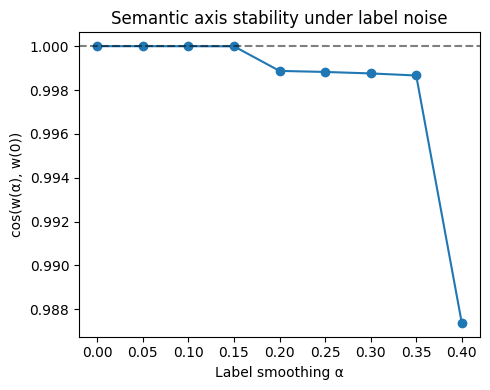

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

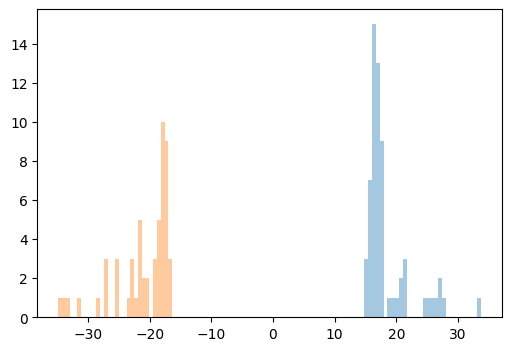

In [4]:
w0 = Ws[0]
cos_sim = Ws @ w0

plt.figure(figsize=(5,4))
plt.plot(alphas, cos_sim, "-o")
plt.axhline(1.0, color="k", ls="--", alpha=0.5)
plt.xlabel("Label smoothing α")
plt.ylabel("cos(w(α), w(0))")
plt.title("Semantic axis stability under label noise")
plt.tight_layout()
plt.show()

def margins(X, y, w, scaler):
    Xz = scaler.transform(X)
    m = Xz @ w
    return m[y==1], m[y==0]

plt.figure(figsize=(6,4))
for i, a in enumerate([0.0, 0.1, 0.2, 0.3]):
    w = Ws[i]
    _, scaler = fit_logreg_direction(R, smooth_labels(y, a))
    m_pos, m_neg = margins(R, y, w, scaler)

    plt.hist(m_pos, bins=30, alpha=0.4, label=f"α={a} pos")
    plt.hist(m_neg, bins=30, alpha=0.4, label=f"α={a} neg")

plt.axvline(0, color="k", lw=1)
plt.legend(fontsize=8)
plt.xlabel("margin  y·(wᵀx)")
plt.ylabel("count")
plt.title("Margin distributions cool with label noise")
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
Z = pca.fit_transform(Ws)

plt.figure(figsize=(5,4))
plt.plot(Z[:,0], Z[:,1], "-o")
for i,a in enumerate(alphas):
    plt.text(Z[i,0], Z[i,1], f"{a:.2f}", fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trajectory of decoding axis under label noise")
plt.tight_layout()
plt.show()